# Deep Learning with Python using Keras

## Big idea
We want to build a computer program that can look at a handwritten digit image and predict whether it is `0`, `1`, `2`, ..., or `9`.

This is a **multi-class classification** problem because the answer belongs to one of many possible classes.

## Learning objectives
By the end of this lesson, students should be able to:

1. Explain what deep learning is in simple words.
2. Explain why Keras is used for building neural networks.
3. Load the MNIST handwritten digit dataset.
4. Understand the difference between training data and testing data.
5. Visualize handwritten digit images.
6. Reshape image data from 2D to 1D.
7. Normalize pixel values from `0–255` to `0–1`.
8. Convert labels to one-hot encoded form.
9. Build, compile, train, evaluate, and save a simple neural network model.

## 1. What is deep learning?

**Deep learning** is a branch of machine learning that uses artificial neural networks to learn patterns from data.

A neural network learns by adjusting internal values called **weights** and **biases**.

For this lesson, the model will learn patterns in images of handwritten digits.

For example:

- An image may contain the digit `7`.
- The model will receive the pixel values of that image.
- The model will learn the patterns that make the image look like `7`.
- Later, when it sees a new handwritten digit, it tries to predict the correct class.

## 2. Import the libraries

Before building a machine learning model, we first import the tools we need.

In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

### Explanation of the import code

```python
import numpy as np
```
This imports NumPy and gives it a short name: `np`.  
NumPy is used for numerical operations and array handling.

```python
from tensorflow import keras
```
This imports Keras from TensorFlow. Keras gives us a simple way to build neural networks.

```python
from tensorflow.keras import layers
```
This imports neural network layers.

```python
import matplotlib.pyplot as plt
```
This imports Matplotlib for displaying images and charts.

## 3. Set a random seed

Neural networks usually start with random weights. Because of this, the result may be slightly different each time you run the notebook.

To make the result more consistent, we set a random seed.

In [3]:
keras.utils.set_random_seed(1234)

### Explanation

```python
keras.utils.set_random_seed(1234)
```

This tells Keras/TensorFlow to use a fixed starting point for random operations.

The number `1234` is not special. You can use another number, but using the same number helps produce similar results.

## 4. Load the MNIST dataset

The **MNIST dataset** contains handwritten digits from `0` to `9`.

It contains:

- **60,000 training images**
- **10,000 testing images**
- Each image is **28 by 28 pixels**
- Each image is grayscale, meaning it has only shades of black, white, and gray

The model will learn from the training images and then be tested on images it has not seen before.

In [4]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

### Explanation of the loading code

```python
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()
```

This loads four things:

| Variable | Meaning |
|---|---|
| `train_images` | Images used to teach the model |
| `train_labels` | Correct answers for the training images |
| `test_images` | New images used to test the model |
| `test_labels` | Correct answers for the test images |

A **label** is the correct answer.  
For example, if an image contains a handwritten `5`, then its label is `5`.

## 5. Check the shape of the data

The shape tells us the structure of the data.

For image data, the shape usually tells us:

1. Number of images
2. Height of each image
3. Width of each image

In [5]:
print('Training data shape:', train_images.shape)
print('Testing data shape:', test_images.shape)
print('Training labels shape:', train_labels.shape)
print('Testing labels shape:', test_labels.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)
Training labels shape: (60000,)
Testing labels shape: (10000,)


This means:

- There are `60,000` training images.
- Each training image has size `28 x 28` pixels.
- There are `10,000` testing images.
- Each testing image also has size `28 x 28` pixels.

The label arrays contain one correct answer for each image.

## 6. View some handwritten digit images

It is always good to inspect your data before training a model.

Here, we display the first five training images and their labels.

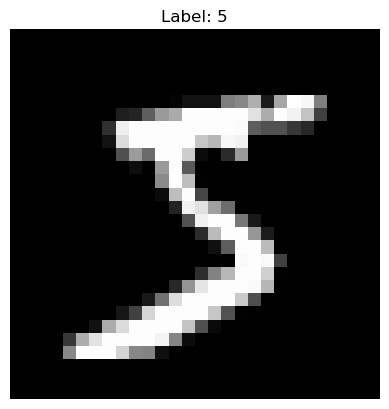

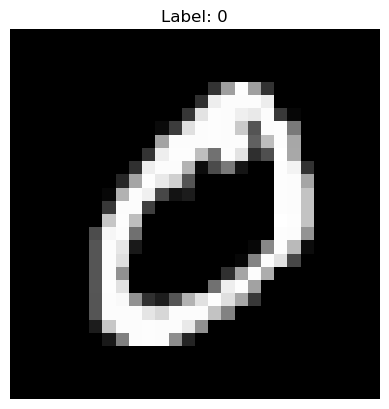

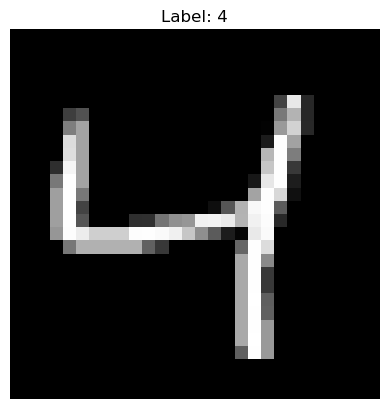

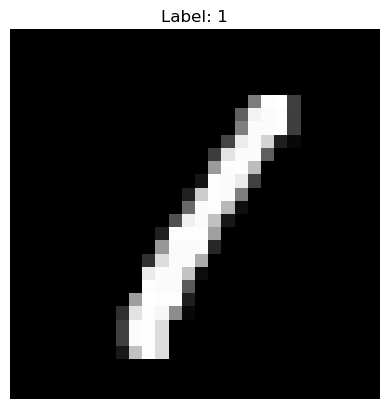

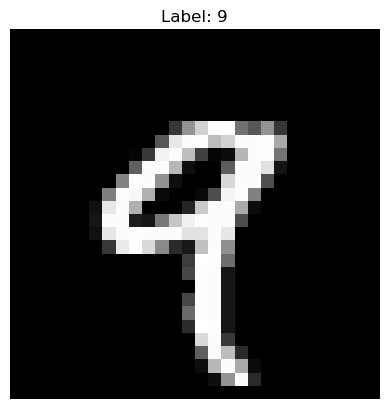

In [6]:
for i in range(5):
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f'Label: {train_labels[i]}')
    plt.axis('off')
    plt.show()

### Explanation of the visualization code

```python
for i in range(5):
```
This loops through the first five images.

```python
plt.imshow(train_images[i], cmap='gray')
```
This displays the image. `cmap='gray'` tells Matplotlib to show it as a grayscale image.

```python
plt.title(f'Label: {train_labels[i]}')
```
This shows the correct answer above the image.

```python
plt.axis('off')
```
This removes the x-axis and y-axis markings so the image looks cleaner.

```python
plt.show()
```
This displays the image.

## 7. Understand pixels

Each MNIST image is made of pixels.

A pixel value usually ranges from:

- `0` = black
- `255` = white
- values between 0 and 255 = different shades of gray

Let us inspect the first image as numbers.

In [7]:
print(train_images[0])
print('Minimum pixel value:', train_images[0].min())
print('Maximum pixel value:', train_images[0].max())

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

## 8. Preprocess the data

Before we train a neural network, we need to prepare the data.

This is called **preprocessing**.

For this notebook, preprocessing has three major parts:

1. Reshape the images.
2. Normalize the pixel values.
3. Convert labels to one-hot encoded vectors.

## 9. Reshape images from 28 × 28 to 784

Each image is currently a 2D matrix of shape `28 x 28`.

But our simple neural network will use a `Dense` layer, and a Dense layer expects each input example to be a flat vector.

So we convert each image:

```text
28 x 28 image  →  784 values
```

Because:

```text
28 × 28 = 784
```

So instead of giving the model a square image, we give it one long row of 784 numbers.

In [8]:
train_images = train_images.reshape(60000, 28 * 28)
test_images = test_images.reshape(10000, 28 * 28)

### Explanation of reshape

```python
train_images.reshape(60000, 28 * 28)
```
This changes the training data from:

```text
(60000, 28, 28)
```

to:

```text
(60000, 784)
```

Meaning:

- We still have `60,000` images.
- But each image is now represented by `784` pixel values.

This does not destroy the information. It only changes the arrangement of the data.

In [9]:
print('Training data shape after reshaping:', train_images.shape)
print('Testing data shape after reshaping:', test_images.shape)

Training data shape after reshaping: (60000, 784)
Testing data shape after reshaping: (10000, 784)


## 10. Normalize the pixel values

The pixel values currently range from `0` to `255`.

Neural networks usually train better when input values are small, commonly between `0` and `1`.

So we divide every pixel value by `255`.

Example:

| Original pixel | After dividing by 255 |
|---|---|
| 0 | 0.0 |
| 127 | 0.498 |
| 255 | 1.0 |

This process is called **normalization**.

In [10]:
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

### Explanation of normalization code

```python
train_images.astype('float32')
```
This converts the pixel values into decimal numbers.

```python
/ 255
```
This scales the values to the range `0` to `1`.

This helps the model train faster and more smoothly.

In [11]:
print('Minimum training pixel value:', train_images.min())
print('Maximum training pixel value:', train_images.max())

Minimum training pixel value: 0.0
Maximum training pixel value: 1.0


## 11. Understand labels before one-hot encoding

The labels are currently ordinary numbers from `0` to `9`.

For example:

```text
5
0
4
1
9
```

But for multi-class classification, we often convert each label into a vector.

This is called **one-hot encoding**.

In [12]:
print('First 10 labels before one-hot encoding:')
print(train_labels[:10])

First 10 labels before one-hot encoding:
[5 0 4 1 9 2 1 3 1 4]


## 12. One-hot encode the labels

One-hot encoding converts a class number into a vector of zeros and ones.

Because we have 10 classes, each label becomes a vector of length 10.

Example:

| Label | One-hot encoding |
|---|---|
| 0 | `[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]` |
| 1 | `[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]` |
| 5 | `[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]` |
| 9 | `[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]` |

The position with `1` represents the correct class.

In [13]:
num_classes = 10
train_labels = keras.utils.to_categorical(train_labels, num_classes)
test_labels = keras.utils.to_categorical(test_labels, num_classes)

### Explanation of one-hot encoding code

```python
num_classes = 10
```
There are 10 possible digits: `0` to `9`.

```python
keras.utils.to_categorical(train_labels, num_classes)
```
This converts the training labels into one-hot encoded vectors.

```python
keras.utils.to_categorical(test_labels, num_classes)
```
This does the same for the test labels.

In [14]:
print('Training labels shape after one-hot encoding:', train_labels.shape)
print('Testing labels shape after one-hot encoding:', test_labels.shape)
print('First encoded label:', train_labels[0])

Training labels shape after one-hot encoding: (60000, 10)
Testing labels shape after one-hot encoding: (10000, 10)
First encoded label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 13. Build a simple neural network model

Now that the data is ready, we can build the model.

We will use a simple **feedforward neural network**.

A feedforward neural network means information moves in one direction:

```text
Input layer → Hidden layer → Output layer
```

The input layer receives the 784 pixel values.

The hidden layer learns patterns.

The output layer gives probabilities for the 10 possible digits.

In [16]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
])

### Explanation of the model code

```python
model = keras.Sequential([...])
```
This creates a model where layers are arranged one after another.

```python
layers.Dense(128, activation='relu', input_shape=(784,))
```
This is the hidden layer.

- `Dense` means every neuron in this layer connects to every input value.
- `128` means the layer has 128 neurons.
- `activation='relu'` helps the network learn non-linear patterns.
- `input_shape=(784,)` means each input image has 784 values.

```python
layers.Dense(10, activation='softmax')
```
This is the output layer.

- `10` means there are 10 output neurons, one for each digit.
- `softmax` converts the outputs into probabilities.

For example, the model may output something like:

```text
Digit 0: 0.01
Digit 1: 0.02
Digit 2: 0.03
...
Digit 7: 0.88
```

The class with the highest probability becomes the prediction.

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## 14. Compile the model

Before training, we must compile the model.

Compiling tells the model:

1. How to measure error.
2. How to improve itself.
3. What metric to report.

In [20]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Explanation of compile code

```python
optimizer='adam'
```
The optimizer updates the model's weights to reduce error. Adam is a popular optimizer.

```python
loss='categorical_crossentropy'
```
The loss function measures how wrong the model is.  
For one-hot encoded multi-class labels, `categorical_crossentropy` is commonly used.

```python
metrics=['accuracy']
```
Accuracy tells us the percentage of predictions the model got correct.

## 15. Train the model

Training is where the model learns from the training data.

Important terms:

- **Epoch**: one full pass through the training data.
- **Batch size**: number of examples processed at a time.
- **Validation split**: a small part of the training data used to check performance during training.

In [21]:
history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8980 - loss: 0.3748 - val_accuracy: 0.9505 - val_loss: 0.1738
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9516 - loss: 0.1714 - val_accuracy: 0.9623 - val_loss: 0.1298
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9648 - loss: 0.1233 - val_accuracy: 0.9675 - val_loss: 0.1104
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9722 - loss: 0.0958 - val_accuracy: 0.9688 - val_loss: 0.0997
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9779 - loss: 0.0773 - val_accuracy: 0.9715 - val_loss: 0.0913


### Explanation of training code

```python
model.fit(train_images, train_labels, ...)
```
This trains the model using the training images and their correct labels.

```python
epochs=5
```
The model will go through the training data 5 times.

```python
batch_size=128
```
The model processes 128 images at a time before updating its weights.

```python
validation_split=0.1
```
This uses 10% of the training data for validation while training.

## 16. Evaluate the model

After training, we test the model using `test_images` and `test_labels`.

This is important because the test data contains images the model did not use for training.

In [22]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print('Test loss:', test_loss)
print('Test accuracy:', test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9718 - loss: 0.0914 
Test loss: 0.0913819670677185
Test accuracy: 0.9718000292778015


### Explanation of evaluation

```python
model.evaluate(test_images, test_labels)
```
This checks how well the model performs on new data.

The two values returned are:

- **Test loss**: how wrong the model is on the test data.
- **Test accuracy**: how many test images the model classified correctly.

A higher accuracy means better performance.

## 17. Make predictions

Now let us use the trained model to predict some test images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


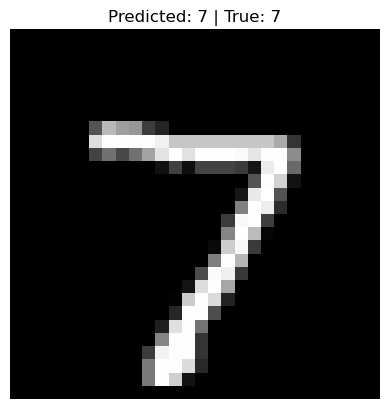

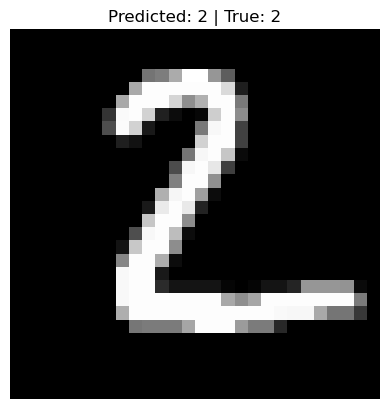

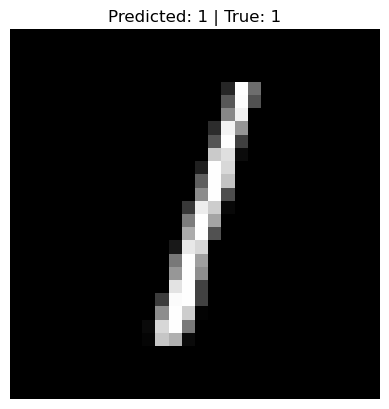

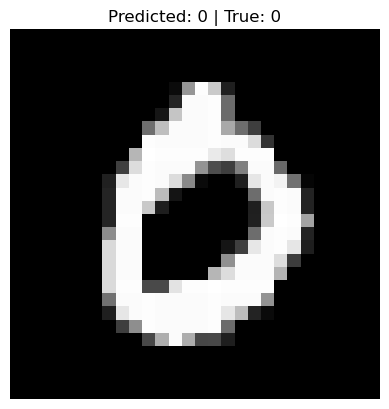

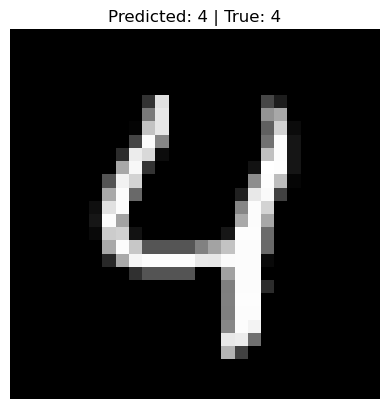

In [23]:
predictions = model.predict(test_images[:5])

for i in range(5):
    predicted_label = np.argmax(predictions[i])
    true_label = np.argmax(test_labels[i])
    
    plt.imshow(test_images[i].reshape(28, 28), cmap='gray')
    plt.title(f'Predicted: {predicted_label} | True: {true_label}')
    plt.axis('off')
    plt.show()

### Explanation of prediction code

```python
predictions = model.predict(test_images[:5])
```
This asks the model to predict the first five test images.

```python
np.argmax(predictions[i])
```
This returns the index with the highest probability.  
That index becomes the predicted digit.

```python
np.argmax(test_labels[i])
```
Because the true label is one-hot encoded, this converts it back to the original digit.

```python
test_images[i].reshape(28, 28)
```
Earlier, we flattened the images into 784 values.  
To display them again, we reshape them back to `28 x 28`.

## 18. Plot training accuracy and loss

The `history` object stores what happened during training.

We can plot accuracy and loss to see whether the model improved over time.

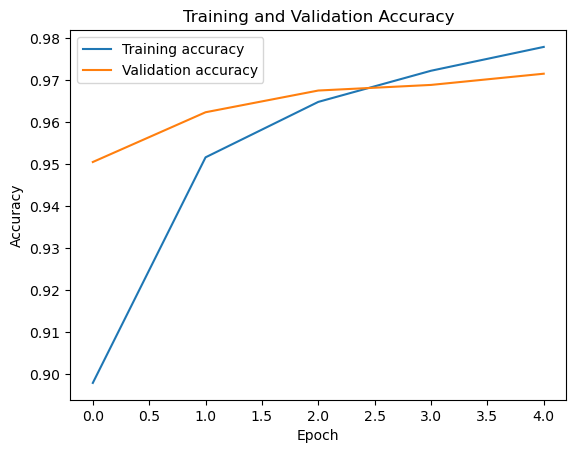

In [24]:
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

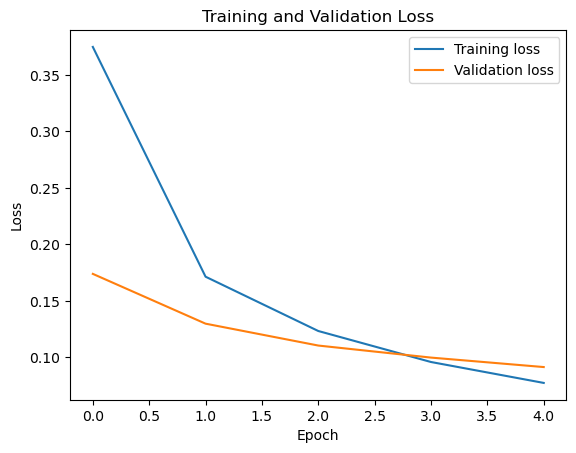

In [25]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

## 19. Save the trained model

After training a model, we may want to save it so that we do not need to train it again every time.

In [26]:
model.save('mnist_digit_model.keras')

### Explanation

```python
model.save('mnist_digit_model.keras')
```
This saves the trained model to a file named `mnist_digit_model.keras`.

Later, you can load it again using:

```python
loaded_model = keras.models.load_model('mnist_digit_model.keras')
```

## 20. Lesson summary


In this lesson, we learned that:

1. Deep learning models can learn patterns from data.
2. Keras makes it easier to build neural networks.
3. MNIST contains handwritten digit images.
4. Training data is used to teach the model.
5. Testing data is used to check whether the model can generalize.
6. Image pixels are numbers.
7. A `28 x 28` image can be flattened into `784` values.
8. Normalization changes pixel values from `0–255` to `0–1`.
9. One-hot encoding converts class labels into vectors.
10. A neural network can be trained to classify handwritten digits.